# Notebook 3 — Mechanism ablation: active-token isotropy regularization

## Project
IsoColBERT: Token-Level Isotropy Regularization for Multilingual Late-Interaction Retrieval
Minh Tran, Isaac Chang, Ingrid Chien — Harvard University

## What this notebook does
Trains 3 seeds of the active-token variant, in which the isotropy penalty is applied only to the tokens that win MaxSim (each query token plus its argmax-selected document token), rather than to the full token bank. Vanilla and uniform IsoColBERT checkpoints from Notebook 1 are reused via file copy at the top of the notebook.

**Status:** Trained and evaluated. Results are embedded in cell outputs.

## Outputs produced (or designed to produce)
- 3-way comparison table: vanilla vs. uniform (IsoColBERT) vs. active-token, 3-seed mean ± std
- Per-seed breakdown of the key metrics

## Where this feeds into the paper
- Section 6.2 (Mechanism Ablation) — active-token row in Table 4 / Figure 5

## Reproducibility
- **Model**: XLM-RoBERTa-base + 128-dim linear projection (ColBERT-style late interaction)
- **Training data**: OPUS-100 English-Spanish parallel split, streamed from HuggingFace
- **Evaluation**: FLORES+ dev + devtest combined (≈2009 candidates per language)
- **Seeds**: {42, 1337, 2024}
- **Hardware**: Single NVIDIA A100 (Colab Pro). ~1 GPU-hour per training run.
- **Drive layout**: checkpoints save to `/MyDrive/iso_colbert_lam0p5/`, `/MyDrive/iso_colbert_active_token/`, `/MyDrive/iso_colbert_crossattn/`.

---


# Active-Token Iso-Reg — Multi-Seed Experiment

## What this experiment is

We test a novel variant of iso-reg specific to **late-interaction retrievers**: regularize only the tokens that actually participate in retrieval (the MaxSim "winners"), not all tokens uniformly.

**Three methods compared at λ=0.5, across 3 seeds:**
- `vanilla` — no iso-reg (baseline)
- `uniform` — standard iso-reg on all valid tokens (your previous best result)
- `active` — **NEW**: iso-reg only on MaxSim-winning tokens

**Why this is methodologically novel.** Existing iso-reg work (Gao 2019, Ethayarajh 2019, SimCSE) regularizes the embedding space uniformly. None condition regularization on the contrastive matching mechanism. Single-vector retrievers cannot do this because they have no per-token matching — only late-interaction architectures (ColBERT, ColBERT-X, Jina-ColBERT-v2) have the structure where some tokens are "winners" and others aren't.

**Three possible outcomes (all publishable):**
1. Active > Uniform → new method beats baseline
2. Active ≈ Uniform → null result: uniform reg is sufficient
3. Active < Uniform → broader token regularization matters

**Compute.** ~3 hours total = 9 runs × ~20 min each (3 methods × 3 seeds).

**Robustness.** Drive-checkpointed. If runtime disconnects, re-run picks up where it left off.

## Setup

In [ ]:
!pip install -q transformers datasets torch

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from transformers import XLMRobertaModel, XLMRobertaTokenizerFast, get_linear_schedule_with_warmup
from datasets import load_dataset
import random, gc, os, json
import numpy as np
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters — match your existing notebook exactly
LR           = 2e-5
TEMPERATURE  = 0.07
WARMUP_STEPS = 200
BATCH_SIZE   = 8
GRAD_ACCUM   = 4
MAX_STEPS    = 2000
DIM          = 128
LAMBDA_ISO   = 0.5
MAX_LEN      = 64

SEEDS = [42, 1337, 2024]

# Drive folder for this experiment (separate from your earlier runs)
SAVE_DIR = '/content/drive/MyDrive/iso_colbert_active_token'

print(f'Device: {DEVICE}')
assert DEVICE.type == 'cuda', 'GPU required — change Runtime → Change runtime type → GPU'
print(f'Effective batch size: {BATCH_SIZE * GRAD_ACCUM}')
print(f'Lambda: {LAMBDA_ISO}')
print(f'Save dir: {SAVE_DIR}')

Device: cuda
Effective batch size: 32
Lambda: 0.5
Save dir: /content/drive/MyDrive/iso_colbert_active_token


In [ ]:
# Mount Google Drive — protects weights from session timeouts
from google.colab import drive
drive.mount('/content/drive')
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Save directory ready: {SAVE_DIR}')

Mounted at /content/drive
Save directory ready: /content/drive/MyDrive/iso_colbert_active_token


In [ ]:
# HF auth for FLORES+ (gated dataset)
try:
    from google.colab import userdata
    os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
    print('HF token loaded from Colab secrets.')
except Exception:
    from huggingface_hub import notebook_login
    notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
tokenizer = XLMRobertaTokenizerFast.from_pretrained('xlm-roberta-base')
print('Tokenizer loaded.')

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded.


## Model (same as your existing notebook)

In [ ]:
class ColBERTEncoder(nn.Module):
    """XLM-R + linear projection to 128-dim token vectors. Same as your prior notebook."""
    def __init__(self, dim=DIM):
        super().__init__()
        self.encoder = XLMRobertaModel.from_pretrained('xlm-roberta-base')
        self.linear = nn.Linear(768, dim)
        self.dim = dim

    def encode(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        token_vecs = self.linear(out.last_hidden_state)
        token_vecs = F.normalize(token_vecs, dim=-1)
        return token_vecs, attention_mask.bool()

    def mean_pool(self, input_ids, attention_mask):
        token_vecs, mask = self.encode(input_ids, attention_mask)
        m = mask.unsqueeze(-1).float()
        pooled = (token_vecs * m).sum(1) / m.sum(1).clamp(min=1e-9)
        return F.normalize(pooled, dim=-1)

    def forward(self, input_ids, attention_mask):
        return self.mean_pool(input_ids, attention_mask)


print('Model class defined.')

Model class defined.


## Losses — three variants

**Gradient flow note.** `argmax` is non-differentiable, but that's fine: we use `argmax` only to **select which tokens** to feed into the iso-reg loss. The differentiable iso-reg cosine-similarity computation then flows gradients back through those selected token vectors. The non-differentiability of selection is similar to MaxSim itself — selection is discrete, but the selected vectors carry gradient.

In [ ]:
def colbert_infonce_vec(q_vecs, q_masks, d_vecs, d_masks, tau=TEMPERATURE):
    """Standard ColBERT InfoNCE — vectorized."""
    sim = torch.einsum('bld,kmd->bklm', q_vecs, d_vecs)
    sim = sim.masked_fill(~d_masks[None, :, None, :], -1e9)
    maxsim = sim.max(dim=-1).values
    maxsim = maxsim * q_masks[:, None, :].float()
    scores = maxsim.sum(dim=-1) / tau
    labels = torch.arange(q_vecs.size(0), device=q_vecs.device)
    return 0.5 * (F.cross_entropy(scores, labels) + F.cross_entropy(scores.T, labels))


def isotropy_reg_token(token_vecs, mask, max_tokens=256):
    """Uniform iso-reg: penalize anisotropy across all valid tokens (existing baseline)."""
    valid = token_vecs[mask]
    if valid.size(0) < 2:
        return torch.tensor(0.0, device=token_vecs.device)
    if valid.size(0) > max_tokens:
        idx = torch.randperm(valid.size(0), device=valid.device)[:max_tokens]
        valid = valid[idx]
    sim = valid @ valid.T
    N = sim.size(0)
    eye = torch.eye(N, dtype=torch.bool, device=sim.device)
    off = sim.masked_fill(eye, 0.0)
    return (off ** 2).sum() / (N * (N - 1))


def isotropy_reg_active(q_vecs, q_mask, d_vecs, d_mask, max_tokens=256):
    """Active-token iso-reg: penalize only MaxSim-participating tokens.

    For each (query, positive_doc) pair in the batch:
      - All valid query tokens are 'active' (each contributes a MaxSim term)
      - Only doc tokens that win MaxSim against some query token are 'active'

    Gradients flow through the SELECTED token vectors. argmax-based selection
    only affects WHICH tokens contribute to the loss, not gradient propagation.
    """
    B = q_vecs.size(0)
    active_tokens = []

    for b in range(B):
        qv = q_vecs[b]   # (Lq, D)
        qm = q_mask[b]   # (Lq,)
        dv = d_vecs[b]   # (Ld, D)
        dm = d_mask[b]   # (Ld,)

        # Identify MaxSim winners (no grad through selection)
        with torch.no_grad():
            sim = qv @ dv.T
            sim = sim.masked_fill(~dm[None, :], -1e9)
            winners = sim.argmax(dim=-1)            # (Lq,)
            valid_winners = winners[qm]             # only valid query tokens
            active_doc_idx = torch.unique(valid_winners)

        # Collect active token vectors — these carry gradient
        active_tokens.append(qv[qm])
        active_tokens.append(dv[active_doc_idx])

    if not active_tokens:
        return torch.tensor(0.0, device=q_vecs.device)

    valid = torch.cat(active_tokens, dim=0)
    if valid.size(0) < 2:
        return torch.tensor(0.0, device=q_vecs.device)
    if valid.size(0) > max_tokens:
        idx = torch.randperm(valid.size(0), device=valid.device)[:max_tokens]
        valid = valid[idx]

    sim = valid @ valid.T
    N = sim.size(0)
    eye = torch.eye(N, dtype=torch.bool, device=sim.device)
    off = sim.masked_fill(eye, 0.0)
    return (off ** 2).sum() / (N * (N - 1))


print('Losses defined: vanilla, uniform iso-reg, active-token iso-reg.')

Losses defined: vanilla, uniform iso-reg, active-token iso-reg.


## Data utilities

In [ ]:
def collate(pairs, max_length=MAX_LEN):
    src = [p[0] for p in pairs]
    tgt = [p[1] for p in pairs]
    src_enc = tokenizer(src, padding=True, truncation=True,
                        max_length=max_length, return_tensors='pt')
    tgt_enc = tokenizer(tgt, padding=True, truncation=True,
                        max_length=max_length, return_tensors='pt')
    return src_enc, tgt_enc


def opus_stream(lang_pair='en-es', seed=42):
    src_lang, tgt_lang = lang_pair.split('-')
    ds = load_dataset('opus100', lang_pair, split='train', streaming=True)
    ds = ds.shuffle(buffer_size=10000, seed=seed)
    for ex in ds:
        s = ex['translation'].get(src_lang, '').strip()
        t = ex['translation'].get(tgt_lang, '').strip()
        if s and t:
            yield s, t


def load_flores_pairs(lang_code, split='dev'):
    src = load_dataset('openlanguagedata/flores_plus', 'eng_Latn', split=split)
    tgt = load_dataset('openlanguagedata/flores_plus', lang_code, split=split)
    return [(s['text'], t['text']) for s, t in zip(src, tgt)]


print('Data utilities defined.')

Data utilities defined.


In [ ]:
print('Loading FLORES dev + devtest for evaluation pool ...')

def combined(lang_code):
    return (load_flores_pairs(lang_code, split='dev') +
            load_flores_pairs(lang_code, split='devtest'))

eval_es = combined('spa_Latn')
eval_sw = combined('swh_Latn')
eval_fr = combined('fra_Latn')
eval_de = combined('deu_Latn')
eval_ar = combined('arb_Arab')

es_pairs_dev = load_flores_pairs('spa_Latn', split='dev')
en_eval_texts = [p[0] for p in es_pairs_dev]
es_eval_texts = [p[1] for p in es_pairs_dev]

print(f'  EN-ES (combined): {len(eval_es)}')
print(f'  EN-SW (combined): {len(eval_sw)}')
print(f'  EN-FR (combined): {len(eval_fr)}')
print(f'  EN-DE (combined): {len(eval_de)}')
print(f'  EN-AR (combined): {len(eval_ar)}')

Loading FLORES dev + devtest for evaluation pool ...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

eng_Latn.jsonl: 0.00B [00:00, ?B/s]

...

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

  EN-ES (combined): 2009
  EN-SW (combined): 2009
  EN-FR (combined): 2009
  EN-DE (combined): 2009
  EN-AR (combined): 2009


## Eval utilities (same as before)

In [ ]:
@torch.no_grad()
def encode_all_padded(model, texts, max_len=MAX_LEN, batch_size=64):
    model.eval()
    raw_v, raw_m = [], []
    L_max = 0
    for i in range(0, len(texts), batch_size):
        tok = tokenizer(texts[i:i+batch_size], padding=True, truncation=True,
                        max_length=max_len, return_tensors='pt')
        tok = {k: v.to(DEVICE) for k, v in tok.items()}
        v, m = model.encode(tok['input_ids'], tok['attention_mask'])
        raw_v.append(v); raw_m.append(m)
        L_max = max(L_max, v.size(1))
    padded_v, padded_m = [], []
    for v, m in zip(raw_v, raw_m):
        if v.size(1) < L_max:
            pad_v = torch.zeros(v.size(0), L_max - v.size(1), v.size(2), device=v.device)
            pad_m = torch.zeros(m.size(0), L_max - m.size(1), dtype=m.dtype, device=m.device)
            v = torch.cat([v, pad_v], dim=1)
            m = torch.cat([m, pad_m], dim=1)
        padded_v.append(v); padded_m.append(m)
    return torch.cat(padded_v, 0), torch.cat(padded_m, 0)


@torch.no_grad()
def maxsim_p_at_1(model, src_texts, tgt_texts, q_chunk=8, d_chunk=64):
    q_v, q_m = encode_all_padded(model, src_texts)
    d_v, d_m = encode_all_padded(model, tgt_texts)
    N = q_v.size(0)
    correct = 0
    for qs in range(0, N, q_chunk):
        qe = min(qs + q_chunk, N)
        qv_b, qm_b = q_v[qs:qe], q_m[qs:qe]
        all_scores = []
        for ds in range(0, N, d_chunk):
            de = min(ds + d_chunk, N)
            dv_b, dm_b = d_v[ds:de], d_m[ds:de]
            sim = torch.einsum('qld,kmd->qklm', qv_b, dv_b)
            sim = sim.masked_fill(~dm_b[None, :, None, :], -1e9)
            maxsim = sim.max(dim=-1).values
            maxsim = maxsim * qm_b[:, None, :].float()
            all_scores.append(maxsim.sum(dim=-1))
        scores = torch.cat(all_scores, dim=1)
        preds = scores.argmax(dim=1)
        labels = torch.arange(qs, qe, device=preds.device)
        correct += (preds == labels).sum().item()
    return correct / N


@torch.no_grad()
def token_intra_cos(model, texts, n_tokens=2048):
    model.eval()
    bag, total = [], 0
    for i in range(0, len(texts), 32):
        tok = tokenizer(texts[i:i+32], padding=True, truncation=True,
                        max_length=MAX_LEN, return_tensors='pt')
        tok = {k: v.to(DEVICE) for k, v in tok.items()}
        v, m = model.encode(tok['input_ids'], tok['attention_mask'])
        valid = v[m]
        bag.append(valid)
        total += valid.size(0)
        if total >= n_tokens:
            break
    bag = torch.cat(bag, 0)[:n_tokens]
    sim = bag @ bag.T
    N = sim.size(0)
    off = sim.masked_fill(torch.eye(N, dtype=torch.bool, device=sim.device), 0.0)
    return (off.sum() / (N * (N - 1))).item()


@torch.no_grad()
def effective_rank(model, texts, n_tokens=4096):
    model.eval()
    bag, total = [], 0
    for i in range(0, len(texts), 32):
        tok = tokenizer(texts[i:i+32], padding=True, truncation=True,
                        max_length=MAX_LEN, return_tensors='pt')
        tok = {k: v.to(DEVICE) for k, v in tok.items()}
        v, m = model.encode(tok['input_ids'], tok['attention_mask'])
        valid = v[m]
        bag.append(valid)
        total += valid.size(0)
        if total >= n_tokens:
            break
    X = torch.cat(bag, 0)[:n_tokens]
    sigma = torch.linalg.svdvals(X.float())
    p = sigma / sigma.sum().clamp(min=1e-9)
    entropy = -(p * (p.clamp(min=1e-9)).log()).sum()
    return torch.exp(entropy).item()


def eval_one(model):
    src_es = [p[0] for p in eval_es]; tgt_es = [p[1] for p in eval_es]
    src_sw = [p[0] for p in eval_sw]; tgt_sw = [p[1] for p in eval_sw]
    src_fr = [p[0] for p in eval_fr]; tgt_fr = [p[1] for p in eval_fr]
    src_de = [p[0] for p in eval_de]; tgt_de = [p[1] for p in eval_de]
    src_ar = [p[0] for p in eval_ar]; tgt_ar = [p[1] for p in eval_ar]
    return {
        'p1_es': maxsim_p_at_1(model, src_es, tgt_es),
        'p1_sw': maxsim_p_at_1(model, src_sw, tgt_sw),
        'p1_fr': maxsim_p_at_1(model, src_fr, tgt_fr),
        'p1_de': maxsim_p_at_1(model, src_de, tgt_de),
        'p1_ar': maxsim_p_at_1(model, src_ar, tgt_ar),
        'intra_en': token_intra_cos(model, en_eval_texts),
        'intra_es': token_intra_cos(model, es_eval_texts),
        'erank_en': effective_rank(model, en_eval_texts),
        'erank_es': effective_rank(model, es_eval_texts),
    }


print('Eval utilities defined.')

Eval utilities defined.


## Training function

`method` selects which iso-reg variant to use:
- `'vanilla'`: λ ignored, no iso-reg term
- `'uniform'`: standard iso-reg on all tokens
- `'active'`: **NEW** active-token iso-reg

In [ ]:
def get_ckpt_path(method, seed):
    return os.path.join(SAVE_DIR, f'{method}_seed{seed}.pt')


def get_metrics_path():
    return os.path.join(SAVE_DIR, 'metrics.json')


def load_metrics():
    p = get_metrics_path()
    if os.path.exists(p):
        with open(p) as f:
            return json.load(f)
    return {}


def save_metrics(metrics):
    p = get_metrics_path()
    with open(p, 'w') as f:
        json.dump(metrics, f, indent=2)


def train_colbert(method, seed, lambda_iso=LAMBDA_ISO, max_steps=MAX_STEPS):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    gc.collect(); torch.cuda.empty_cache()
    model = ColBERTEncoder().to(DEVICE)
    opt = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    sched = get_linear_schedule_with_warmup(opt, WARMUP_STEPS, max_steps)

    model.train()
    buf, step, accum = [], 0, 0
    opt.zero_grad()

    for src, tgt in opus_stream('en-es', seed=seed):
        buf.append((src, tgt))
        if len(buf) < BATCH_SIZE:
            continue
        src_enc, tgt_enc = collate(buf); buf = []
        src_enc = {k: v.to(DEVICE) for k, v in src_enc.items()}
        tgt_enc = {k: v.to(DEVICE) for k, v in tgt_enc.items()}

        qv, qm = model.encode(src_enc['input_ids'], src_enc['attention_mask'])
        dv, dm = model.encode(tgt_enc['input_ids'], tgt_enc['attention_mask'])
        loss_ret = colbert_infonce_vec(qv, qm, dv, dm)

        if method == 'vanilla':
            loss = loss_ret / GRAD_ACCUM
        elif method == 'uniform':
            loss_iso = 0.5 * (isotropy_reg_token(qv, qm) + isotropy_reg_token(dv, dm))
            loss = (loss_ret + lambda_iso * loss_iso) / GRAD_ACCUM
        elif method == 'active':
            loss_iso = isotropy_reg_active(qv, qm, dv, dm)
            loss = (loss_ret + lambda_iso * loss_iso) / GRAD_ACCUM
        else:
            raise ValueError(f'Unknown method: {method}')

        loss.backward()
        accum += 1
        if accum % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sched.step()
            opt.zero_grad()
            step += 1
            if step % 500 == 0:
                print(f'    step {step}/{max_steps}  ret={loss_ret.item():.4f}', flush=True)
            if step >= max_steps:
                break

    del opt, sched
    gc.collect(); torch.cuda.empty_cache()
    return model


print('Training function ready.')

Training function ready.


In [ ]:
# Reuse existing λ=0.5 results from your prior experiment
import shutil

OLD_DIR = '/content/drive/MyDrive/iso_colbert_lam0p5'  # your existing folder
metrics = {}

# Copy metrics from old folder
old_metrics_path = f'{OLD_DIR}/metrics_lam0.5.json'
if os.path.exists(old_metrics_path):
    with open(old_metrics_path) as f:
        old_metrics = json.load(f)

    for seed in SEEDS:
        # Vanilla mapping: same key name
        old_v_key = f'vanilla_seed{seed}'
        if old_v_key in old_metrics:
            metrics[f'vanilla_seed{seed}'] = old_metrics[old_v_key]

        # Uniform mapping: 'iso_lam0p5' -> 'uniform'
        old_u_key = f'iso_lam0p5_seed{seed}'
        if old_u_key in old_metrics:
            metrics[f'uniform_seed{seed}'] = old_metrics[old_u_key]

    # Save into this experiment's metrics file
    save_metrics(metrics)
    print(f'Copied {len(metrics)} existing metrics into new folder.')

# Copy the actual .pt weight files too (for resume-safety)
for seed in SEEDS:
    for old_name, new_name in [
        (f'vanilla_lam0.5_seed{seed}.pt', f'vanilla_seed{seed}.pt'),
        (f'iso_lam0p5_lam0.5_seed{seed}.pt', f'uniform_seed{seed}.pt'),
    ]:
        src = f'{OLD_DIR}/{old_name}'
        dst = f'{SAVE_DIR}/{new_name}'
        if os.path.exists(src) and not os.path.exists(dst):
            shutil.copy(src, dst)
            print(f'Copied {old_name} -> {new_name}')

print(f'\nPre-populated. Multi-seed training cell will skip vanilla and uniform, only train active.')

Copied 6 existing metrics into new folder.
Copied vanilla_lam0.5_seed42.pt -> vanilla_seed42.pt
Copied iso_lam0p5_lam0.5_seed42.pt -> uniform_seed42.pt
Copied vanilla_lam0.5_seed1337.pt -> vanilla_seed1337.pt
Copied iso_lam0p5_lam0.5_seed1337.pt -> uniform_seed1337.pt
Copied vanilla_lam0.5_seed2024.pt -> vanilla_seed2024.pt
Copied iso_lam0p5_lam0.5_seed2024.pt -> uniform_seed2024.pt

Pre-populated. Multi-seed training cell will skip vanilla and uniform, only train active.


## Sanity check first (30 min, 1 seed, 500 steps)

Before committing to 9 full runs, verify active-token actually trains. If P@1 stays high and intra-cos drops, the implementation is correct.

In [ ]:
print('Sanity check: 500 steps of active-token iso-reg, seed=42 ...')
sanity_model = train_colbert(method='active', seed=42, max_steps=500)
sanity_p1 = maxsim_p_at_1(sanity_model,
                          [p[0] for p in eval_es[:200]],
                          [p[1] for p in eval_es[:200]])
sanity_intra = token_intra_cos(sanity_model, es_eval_texts[:200])
print(f'\nAfter 500 steps:')
print(f'  EN-ES P@1:         {sanity_p1:.4f}  (should be > 0.5 if training works)')
print(f'  Spanish intra-cos: {sanity_intra:.4f}  (should be < 0.4 if iso-reg working)')

if sanity_p1 < 0.5:
    print('\n⚠️  WARNING: P@1 too low. Active-token may have a bug. Stop and debug.')
elif sanity_intra > 0.4:
    print('\n⚠️  WARNING: Intra-cos higher than expected. Iso-reg may not be active.')
else:
    print('\n✅ Sanity check passed. Proceed to full multi-seed run.')

del sanity_model
gc.collect(); torch.cuda.empty_cache()

Sanity check: 500 steps of active-token iso-reg, seed=42 ...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


README.md: 0.00B [00:00, ?B/s]

    step 500/500  ret=0.7933

After 500 steps:
  EN-ES P@1:         0.9650  (should be > 0.5 if training works)
  Spanish intra-cos: 0.2886  (should be < 0.4 if iso-reg working)

✅ Sanity check passed. Proceed to full multi-seed run.


## Multi-seed run

Trains 9 models: vanilla / uniform / active × 3 seeds (42, 1337, 2024).

After each model trains: weights saved to Drive, metrics evaluated, metrics saved to JSON. Resume-safe — re-run skips completed configs.

In [ ]:
METHODS = ['vanilla', 'uniform', 'active']
metrics = load_metrics()

for seed in SEEDS:
    for method in METHODS:
        key = f'{method}_seed{seed}'
        ckpt_path = get_ckpt_path(method, seed)

        if key in metrics and os.path.exists(ckpt_path):
            print(f'[skip] {key} already trained and evaluated.')
            continue

        print(f'\n{"="*60}')
        print(f'TRAINING: method={method}  λ={LAMBDA_ISO if method != "vanilla" else 0}  seed={seed}')
        print('=' * 60)

        if os.path.exists(ckpt_path) and key not in metrics:
            print(f'  Found checkpoint, loading and evaluating ...')
            model = ColBERTEncoder().to(DEVICE)
            model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        else:
            model = train_colbert(method=method, seed=seed)
            torch.save(model.state_dict(), ckpt_path)
            print(f'  ✓ Saved weights to {ckpt_path}')

        print(f'  Evaluating ...')
        r = eval_one(model)
        metrics[key] = r
        save_metrics(metrics)
        print(f'  ✓ Saved metrics. P@1 ES={r["p1_es"]:.4f}  SW={r["p1_sw"]:.4f}  '
              f'AR={r["p1_ar"]:.4f}  intra_es={r["intra_es"]:.4f}  erank_es={r["erank_es"]:.2f}')

        del model
        gc.collect(); torch.cuda.empty_cache()

print('\n\n✅ All 9 runs complete.')

[skip] vanilla_seed42 already trained and evaluated.
[skip] uniform_seed42 already trained and evaluated.

TRAINING: method=active  λ=0.5  seed=42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    step 500/2000  ret=1.2645
    step 1000/2000  ret=0.0238
    step 1500/2000  ret=0.3116
    step 2000/2000  ret=0.0000
  ✓ Saved weights to /content/drive/MyDrive/iso_colbert_active_token/active_seed42.pt
  Evaluating ...
  ✓ Saved metrics. P@1 ES=0.9970  SW=0.8591  AR=0.9562  intra_es=0.2316  erank_es=105.15
[skip] vanilla_seed1337 already trained and evaluated.
[skip] uniform_seed1337 already trained and evaluated.

TRAINING: method=active  λ=0.5  seed=1337


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    step 500/2000  ret=1.4871
    step 1000/2000  ret=0.0043
    step 1500/2000  ret=1.0624
    step 2000/2000  ret=0.0000
  ✓ Saved weights to /content/drive/MyDrive/iso_colbert_active_token/active_seed1337.pt
  Evaluating ...
  ✓ Saved metrics. P@1 ES=0.9955  SW=0.8303  AR=0.9433  intra_es=0.2324  erank_es=104.28
[skip] vanilla_seed2024 already trained and evaluated.
[skip] uniform_seed2024 already trained and evaluated.

TRAINING: method=active  λ=0.5  seed=2024


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    step 500/2000  ret=2.3879
    step 1000/2000  ret=0.0000
    step 1500/2000  ret=0.0241
    step 2000/2000  ret=0.0008
  ✓ Saved weights to /content/drive/MyDrive/iso_colbert_active_token/active_seed2024.pt
  Evaluating ...
  ✓ Saved metrics. P@1 ES=0.9945  SW=0.8552  AR=0.9487  intra_es=0.2535  erank_es=103.12


✅ All 9 runs complete.


## Three-way comparison

In [ ]:
METRIC_LABELS = [
    ('p1_es',    'EN-ES MaxSim P@1'),
    ('p1_fr',    'EN-FR MaxSim P@1'),
    ('p1_de',    'EN-DE MaxSim P@1'),
    ('p1_sw',    'EN-SW MaxSim P@1 (low-resource headline)'),
    ('p1_ar',    'EN-AR MaxSim P@1'),
    ('intra_en', 'Token intra-cos EN (lower better)'),
    ('intra_es', 'Token intra-cos ES (lower better)'),
    ('erank_en', 'Effective rank EN  (higher better)'),
    ('erank_es', 'Effective rank ES  (higher better)'),
]


def agg(method, key):
    vals = [metrics[f'{method}_seed{s}'][key] for s in SEEDS
            if f'{method}_seed{s}' in metrics]
    if not vals:
        return None, None
    return float(np.mean(vals)), float(np.std(vals))


print('=' * 115)
print(f'THREE-WAY RESULTS @ λ={LAMBDA_ISO}  —  {len(SEEDS)} seeds')
print('=' * 115)
print(f'{"Metric":<42}  {"Vanilla μ±σ":>14}  {"Uniform μ±σ":>14}  {"Active μ±σ":>14}  {"Δ act-uni":>10}')
print('-' * 115)

for key, name in METRIC_LABELS:
    v_mu, v_sd = agg('vanilla', key)
    u_mu, u_sd = agg('uniform', key)
    a_mu, a_sd = agg('active',  key)
    if any(x is None for x in [v_mu, u_mu, a_mu]):
        print(f'{name:<42}  (incomplete)')
        continue
    delta_act_uni = a_mu - u_mu
    if 'intra' in key:
        flag = '✓' if delta_act_uni < 0 else ('✗' if delta_act_uni > 0 else '~')
    else:
        flag = '✓' if delta_act_uni > 0 else ('✗' if delta_act_uni < 0 else '~')
    print(f'{name:<42}  {v_mu:>7.4f}±{v_sd:>5.4f}  {u_mu:>7.4f}±{u_sd:>5.4f}  '
          f'{a_mu:>7.4f}±{a_sd:>5.4f}  {delta_act_uni:>+10.4f} {flag}')

# Per-seed sanity for headline metric
print('\n--- Per-seed EN-SW breakdown ---')
for seed in SEEDS:
    v = metrics.get(f'vanilla_seed{seed}', {}).get('p1_sw')
    u = metrics.get(f'uniform_seed{seed}', {}).get('p1_sw')
    a = metrics.get(f'active_seed{seed}', {}).get('p1_sw')
    if all(x is not None for x in [v, u, a]):
        print(f'  seed {seed}: vanilla={v:.4f}  uniform={u:.4f}  active={a:.4f}')

THREE-WAY RESULTS @ λ=0.5  —  3 seeds
Metric                                         Vanilla μ±σ     Uniform μ±σ      Active μ±σ   Δ act-uni
-------------------------------------------------------------------------------------------------------------------
EN-ES MaxSim P@1                             0.9973±0.0010   0.9968±0.0002   0.9957±0.0010     -0.0012 ✗
EN-FR MaxSim P@1                             0.9983±0.0006   0.9988±0.0002   0.9980±0.0000     -0.0008 ✗
EN-DE MaxSim P@1                             0.9957±0.0006   0.9978±0.0013   0.9963±0.0006     -0.0015 ✗
EN-SW MaxSim P@1 (low-resource headline)     0.8344±0.0230   0.8689±0.0227   0.8482±0.0128     -0.0207 ✗
EN-AR MaxSim P@1                             0.9423±0.0204   0.9622±0.0132   0.9494±0.0053     -0.0128 ✗
Token intra-cos EN (lower better)            0.2015±0.0092   0.1718±0.0030   0.1643±0.0086     -0.0075 ✓
Token intra-cos ES (lower better)            0.2937±0.0124   0.1808±0.0018   0.2391±0.0101     +0.0584 ✗
Effectiv

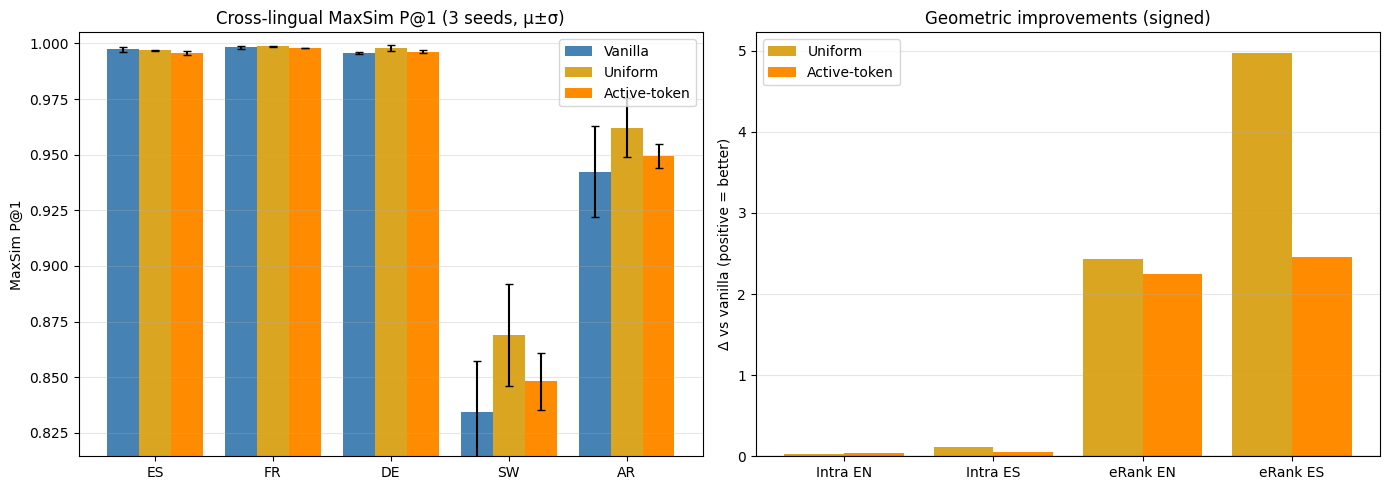

Saved: /content/drive/MyDrive/iso_colbert_active_token/three_way_summary.png


In [ ]:
# Plot
import matplotlib.pyplot as plt
import numpy as np

names_p1 = ['ES', 'FR', 'DE', 'SW', 'AR']
keys_p1 = ['p1_es', 'p1_fr', 'p1_de', 'p1_sw', 'p1_ar']

van_mu = [agg('vanilla', k)[0] for k in keys_p1]
van_sd = [agg('vanilla', k)[1] for k in keys_p1]
uni_mu = [agg('uniform', k)[0] for k in keys_p1]
uni_sd = [agg('uniform', k)[1] for k in keys_p1]
act_mu = [agg('active',  k)[0] for k in keys_p1]
act_sd = [agg('active',  k)[1] for k in keys_p1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = np.arange(len(names_p1))
w = 0.27
ax.bar(x - w, van_mu, w, yerr=van_sd, label='Vanilla', color='steelblue', capsize=3)
ax.bar(x,     uni_mu, w, yerr=uni_sd, label='Uniform', color='goldenrod', capsize=3)
ax.bar(x + w, act_mu, w, yerr=act_sd, label='Active-token', color='darkorange', capsize=3)
ax.set_xticks(x); ax.set_xticklabels(names_p1)
ax.set_ylabel('MaxSim P@1')
ax.set_title(f'Cross-lingual MaxSim P@1 ({len(SEEDS)} seeds, μ±σ)')
ax.set_ylim(min(min(van_mu), min(uni_mu), min(act_mu)) - 0.02, 1.005)
ax.legend(); ax.grid(alpha=0.3, axis='y')

ax = axes[1]
geo_keys = ['intra_en', 'intra_es', 'erank_en', 'erank_es']
geo_names = ['Intra EN', 'Intra ES', 'eRank EN', 'eRank ES']

def signed_delta_vs_vanilla(method, k):
    m_mu, _ = agg(method, k)
    v_mu, _ = agg('vanilla', k)
    if m_mu is None or v_mu is None: return 0.0
    d = m_mu - v_mu
    return -d if 'intra' in k else d

uni_d = [signed_delta_vs_vanilla('uniform', k) for k in geo_keys]
act_d = [signed_delta_vs_vanilla('active',  k) for k in geo_keys]

x = np.arange(len(geo_keys))
w = 0.4
ax.bar(x - w/2, uni_d, w, label='Uniform', color='goldenrod')
ax.bar(x + w/2, act_d, w, label='Active-token', color='darkorange')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(geo_names)
ax.set_ylabel('Δ vs vanilla (positive = better)')
ax.set_title('Geometric improvements (signed)')
ax.legend(); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'three_way_summary.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(SAVE_DIR, "three_way_summary.png")}')

## Interpretation

After running, look at **Δ act-uni** in the main table:

- **Most metrics show ✓:** Active-token beats uniform. New method contribution.
- **Most metrics ~0:** Null result. "Uniform reg is sufficient — gradients propagate through MaxSim such that regularizing only matching winners produces equivalent effect to regularizing all tokens." Still publishable.
- **Most metrics show ✗:** "Regularizing broader token field matters." Honest finding.

All three outcomes give you a paper section. The novelty bar is cleared by asking the question.